In [1]:
from langchain.globals import set_debug, set_verbose
set_debug(False)
set_verbose(False)

In [2]:
import pickle

'''
config = {
    "configurable": {
        "profile": profile,
        "joboffer": joboffer,
    }
}

with open('saved_config.pkl', 'wb') as f:
    pickle.dump(dictionary, f)
'''

with open('db.pkl', 'rb') as f:
    config = pickle.load(f)

config

profile = config['profile']
joboffer = config['joboffer']
joboffer


# read json file for profile
import json
from utils.profile_formatter import formatProfile
with open('/Users/aberman/Documents/Workshop/repio-matcher/local-test/profile-jeremie.json', 'r') as f:
    profile = json.load(f)
profile = formatProfile(profile)
profile

Profile(country='France', city='Rueil-Malmaison', state='Île-de-France', headline='Chef de projet Data & CRM chez Picard Surgelés', summary="Après une formation d'Ingénieur Généraliste spécialisée en Informatique décisionnel conclue par un mémoire en accord avec Vinci Construction France sur la centralisation et à la supervision des données applicatives.\n\nJe suis aujourd'hui en poste pouvant impliquer les domaines suivants :\n\n- de l'analyse de données\n- le Big Data principalement orienté DataViz\n- la Business Intelligence (BI)\n\nTechnos : Elastic / Hadoop / R / Python / BI : PowerBI, Tableau, Qlik", connectionCount=None, followersCount=None, isCreator=None, isHiring=None, isOpenToWork=None, linkedin_id='jeremie-myara', skills=['HTML5', 'CSS', 'C', 'Java', 'JavaScript', 'Oracle SQL Developer', 'Linux', 'Gestion de projet', 'Microsoft Excel', 'PHP', 'Programmation web', 'Microsoft PowerPoint', 'Microsoft Word', 'Feuilles de Style en cascade (CSS)', 'ElasticSearch'], certifications

In [3]:
import json
from utils.profile_formatter import formatProfile

with open("/Users/aberman/Documents/Workshop/repio-matcher/local-test/profile-leopold.json", "r") as file:
        profile_data = json.load(file)

profile = formatProfile(profile_data)
profile

""" 
from utils.job_offer_formatter import formatJobOffer
# reed virgil.txt file and put in string
joboffer_data = open("/Users/aberman/Documents/Workshop/repio-matcher/virgil.txt", "r").read()
joboffer = formatJobOffer(joboffer_data) 
"""

profile

Profile(country='France', city='Paris', state='Île-de-France', headline='Project manager @Virgil', summary='', connectionCount=None, followersCount=None, isCreator=None, isHiring=None, isOpenToWork=None, linkedin_id='léopold-maudelonde', skills=['Entrepreneuriat', 'Gestion de projets', 'Microsoft Excel', 'Travail d’équipe', 'Génie civil', 'Anglais'], certifications=[], educations=[ProfileEducation(startsAt=datetime.datetime(2020, 12, 30, 23, 0, tzinfo=datetime.timezone.utc), endsAt=datetime.datetime(2021, 12, 30, 23, 0, tzinfo=datetime.timezone.utc), school='ESCP Business School', fieldOfStudy='', description='', grade='', degree='MS Innover et entreprendre', linkedin_url='https://www.linkedin.com/school/escp-business-school/'), ProfileEducation(startsAt=datetime.datetime(2015, 12, 30, 23, 0, tzinfo=datetime.timezone.utc), endsAt=datetime.datetime(2017, 12, 30, 23, 0, tzinfo=datetime.timezone.utc), school='Lycée Chateaubriand', fieldOfStudy='', description='', grade='', degree='Classes

In [4]:
""" import pickle

data = {
  "profile": profile,
  "joboffer": joboffer
}

with open('db.pkl', 'wb') as f:
  pickle.dump(data, f) """

' import pickle\n\ndata = {\n  "profile": profile,\n  "joboffer": joboffer\n}\n\nwith open(\'db.pkl\', \'wb\') as f:\n  pickle.dump(data, f) '

In [5]:
from matcher.models.scorecard import load_scorecard_from_json, filter_criteria_by_importance

try:
  scorecard = load_scorecard_from_json("/Users/aberman/Documents/Workshop/repio-matcher/local-test/scorecard.json")
  filtered = filter_criteria_by_importance(scorecard,'experience')
  print(filtered)
except Exception as e:
  print(f"Error loading scorecard: {e}")

ImportError: cannot import name 'filter_criteria_by_importance' from 'app.matcher.models.scorecard' (/Users/aberman/Documents/Workshop/repio-matcher/app/matcher/models/scorecard.py)

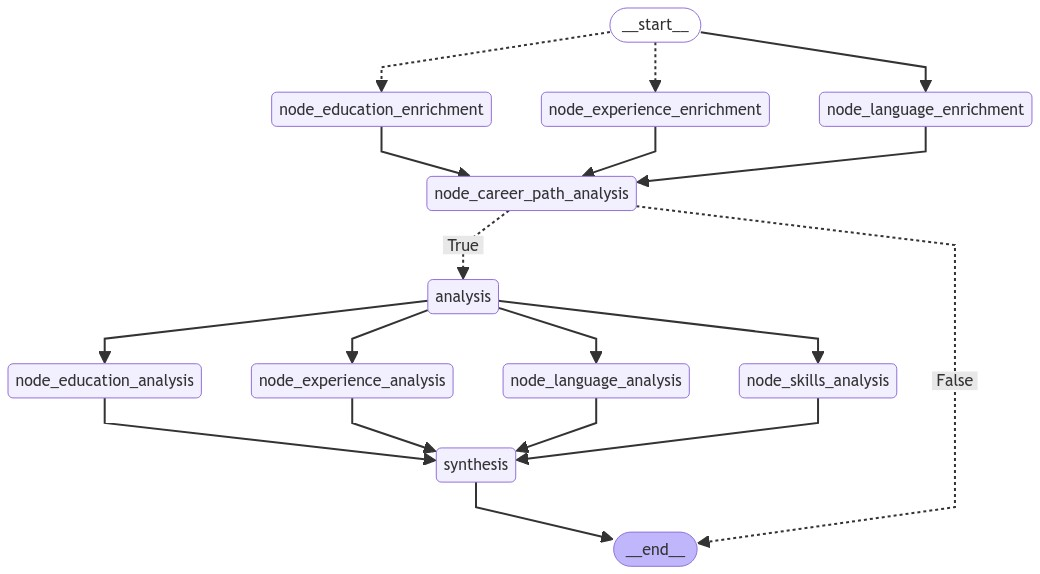

/Users/aberman/Documents/Workshop/repio-matcher/.venv/lib/python3.12/site-packages/langchain_core/_api/beta_decorator.py:87: LangChainBetaWarning: The function `loads` is in beta. It is actively being worked on, so the API may change.
  warn_beta(
/Users/aberman/Documents/Workshop/repio-matcher/.venv/lib/python3.12/site-packages/langchain_core/_api/beta_decorator.py:87: LangChainBetaWarning: The function `init_chat_model` is in beta. It is actively being worked on, so the API may change.
  warn_beta(


Final Score: 0.59


In [ ]:
from dotenv import load_dotenv
load_dotenv()

from matcher.graph import compile_graph
app = compile_graph()

from IPython.display import Image, display
display(Image(app.get_graph(xray=1).draw_mermaid_png()))

inputs = {"messages": [("user", "You are a recruiter.")], "profile": profile, "job_offer": joboffer, "scorecard": scorecard}

res = app.invoke(inputs)

In [ ]:
res

{'profile': Profile(country='France', city='Rueil-Malmaison', state='Île-de-France', headline='Consultant Junior @PMP Strategy', summary='', connectionCount=None, followersCount=None, isCreator=None, isHiring=None, isOpenToWork=None, linkedin_id='auxence-jiguet', skills=['Planification stratégique', 'Stratégie d’entreprise', 'React.js', 'NestJS', 'Tableau', 'Rapports et analyses', 'Python (langage de programmation)', 'SQL', 'Feuilles de calcul', 'Gestion de projet', 'Gestion de l’innovation', 'Pandas (logiciel)', 'Analyse de données', 'Apprentissage automatique'], certifications=[], educations=[ProfileEducation(startsAt=datetime.datetime(2022, 12, 30, 23, 0, tzinfo=datetime.timezone.utc), endsAt=datetime.datetime(2023, 12, 30, 23, 0, tzinfo=datetime.timezone.utc), school='emlyon business school', fieldOfStudy='', description='', grade='', degree='Master 2 (M2) – Master in Management', linkedin_url='https://www.linkedin.com/school/em-lyon-business-school/'), ProfileEducation(startsAt=da

In [ ]:
# add knowledge points
from matcher.tools.knowledge_point import get_knowledge_points


test = get_knowledge_points(["EDUCATION"])
test

[KnowledgePoint(description='If the school is public, then it is considered more prestigious than a private school', type='EDUCATION'),
 KnowledgePoint(description='Short code bootcamps do not necessarily indicate great expertise in coding', type='EDUCATION')]